In [1]:
#load imbalanced data
import pandas as pd
df=pd.read_csv('unbalanced_dataset.csv')

In [2]:
#view
df.head()

,Rating,Review
0,1.0,selfie camera is too worst and the images comi...
1,1.0,very bad product does not work properly even a...
2,1.0,just bought apple iphone s on monday i am disa...
3,1.0,so far having a lot of trouble i am a amazon p...
4,1.0,this phone is not worth for k amount as featur...


1.stop word removal

In [3]:
#install & import required libraries
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
import string

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
#defining stopword removal function
stop_words = set(stopwords.words('english'))
punctuations = string.punctuation

def remove_stopwords(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in punctuations])
    # Tokenize and remove stopwords
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return ' '.join(filtered)

In [5]:
#apply function to imbalanced data
df['Review'] = df['Review'].astype(str).apply(remove_stopwords)

In [6]:
#view
df['Review'].head()

0    selfie camera worst images coming worst mp pho...
1    bad product work properly even replacing want ...
2    bought apple iphone monday disappointing first...
3    far lot trouble amazon prime member alexa keep...
4              phone worth k amount features also good
Name: Review, dtype: object

In [7]:
#print sample stop words
from nltk.corpus import stopwords

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Print first 20 stopwords
print("Sample Stop Words:")
print(list(stop_words)[:20])

Sample Stop Words:
['during', "you'd", 'very', 'just', 'shouldn', 'to', 'your', "we've", 'needn', 'in', 'that', 'y', 'again', 'from', "you'll", "don't", 'down', 'no', 'of', "she'd"]


2.Lemmatization

In [8]:
#required libraries
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [9]:
#defining lemmatization function
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized)

In [10]:
#apply function on imbalanced data
df['Review'] = df['Review'].apply(lemmatize_text)

In [11]:
#view
df['Review'].head()

0    selfie camera worst image coming worst mp phon...
1    bad product work properly even replacing want ...
2    bought apple iphone monday disappointing first...
3    far lot trouble amazon prime member alexa keep...
4               phone worth k amount feature also good
Name: Review, dtype: object

3.filter out long & short reviews

In [12]:
# Count reviews with fewer than 3 words
short_reviews_count = df['Review'].apply(lambda x: len(x.split()) < 3).sum()

# Count reviews with more than 100 words (or any threshold you prefer)
long_reviews_count = df['Review'].apply(lambda x: len(x.split()) > 200).sum()

print(f"Reviews with fewer than 3 words: {short_reviews_count}")
print(f"Reviews with more than 100 words: {long_reviews_count}")

Reviews with fewer than 3 words: 603
Reviews with more than 100 words: 31


In [13]:
# Keep only reviews that have word count between 3 and 200
filtered_df = df[df['Review'].apply(lambda x: 3 <= len(x.split()) <= 200)].reset_index(drop=True)

In [14]:
#rating class distribution
filtered_df['Rating'].value_counts().sort_index()

Rating
1.0     932
2.0    1398
3.0    2374
4.0    2837
5.0    1825
Name: count, dtype: int64

In [15]:
#check nulls
filtered_df.isnull().sum()

Rating    0
Review    0
dtype: int64

In [16]:
#check duplicates
filtered_df.duplicated().sum()

np.int64(441)

In [17]:
#remove duplicate
filtered_df.drop_duplicates(inplace=True)

In [18]:
#rating class distribution
filtered_df['Rating'].value_counts().sort_index()

Rating
1.0     904
2.0    1221
3.0    2209
4.0    2773
5.0    1818
Name: count, dtype: int64

4.visualizations

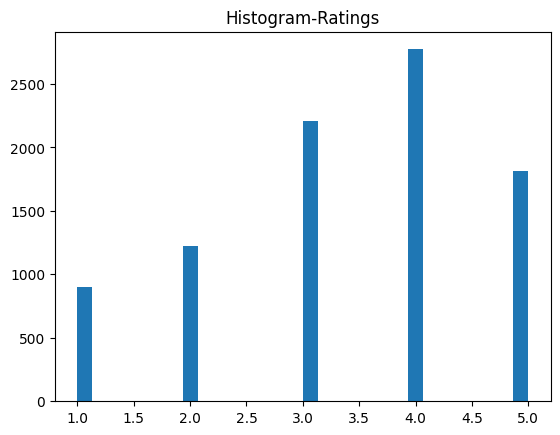

In [19]:
import matplotlib.pyplot as plt
#histogram of rating
plt.hist(filtered_df['Rating'],bins=30)
plt.title('Histogram-Ratings')
plt.show()

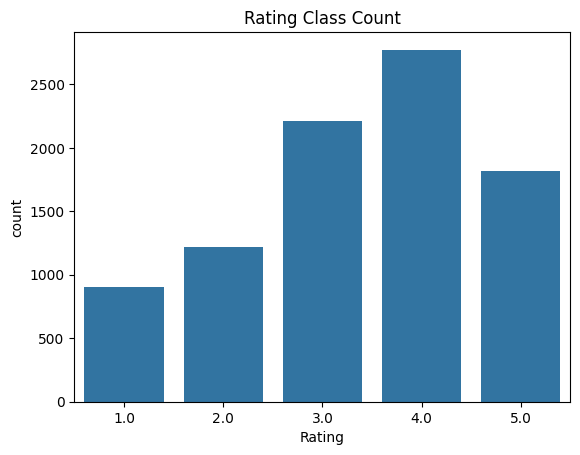

In [20]:
import seaborn as sns
#Count plot (for categorical data)
sns.countplot(x='Rating', data=filtered_df)
plt.title("Rating Class Count")
plt.show()

5.shuffle data

In [21]:
# Shuffle the imbalanced data
imbalanced_df_final = filtered_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [22]:
#view
imbalanced_df_final.head()

,Rating,Review
0,4.0,battery life really low one opt plus model
1,4.0,card work well purchased gb use phone store lo...
2,1.0,product recieved working remote getting paired
3,5.0,great fit easy dress lovely shade bluethis def...
4,4.0,work great wish voice text capability phone in...


Print Min/Max Review Length and Counts

In [23]:
for rating in sorted(imbalanced_df_final['Rating'].unique()):
    # Filter data by rating
    subset = imbalanced_df_final[imbalanced_df_final['Rating'] == rating]
    
    # Compute review lengths (word count)
    lengths = subset['Review'].apply(lambda x: len(x.split()))
    
    min_len = lengths.min()
    max_len = lengths.max()
    
    min_count = (lengths == min_len).sum()
    max_count = (lengths == max_len).sum()
    
    min_sample = subset[lengths == min_len].iloc[0]['Review']
    max_sample = subset[lengths == max_len].iloc[0]['Review']
    
    print(f"\n🔹 Rating: {int(rating)}")
    print(f"  • Min review length: {min_len} words (Count: {min_count})")
    print(f"    Sample: {min_sample}")
    print(f"  • Max review length: {max_len} words (Count: {max_count})")
    print(f"    Sample: {max_sample}")



🔹 Rating: 1
  • Min review length: 3 words (Count: 57)
    Sample: installation bad position
  • Max review length: 165 words (Count: 1)
    Sample: get fooled positive review old saying get pay totally valid product start power consumption specification listed watt tv consumes much higher purchased primary reason would get extended time ups battery owing power issue area picture quality hd signal fairly good definitely par k tv reasonably reliable brand need pair speaker connected good sound tv give something barely hear thats wireless streaming fast picture quality streaming netflix tv appears grainy poor quality cannot watch youtube netflix k tv reasonable video quality sure see believe finally issue screen reflection day time one feature led tv panel reflection generally minimal one ensure see clearly glory finally build quality tv feel brittle matter time something go bust mentioned several review amazon return amazon item like television long drawn affair first time experience a

6.display sample reviews per rating

In [24]:
for rating in sorted(imbalanced_df_final['Rating'].unique()):
    print(f"\n Rating: {int(rating)}")
    samples = imbalanced_df_final[imbalanced_df_final['Rating'] == rating].sample(3, random_state=42)
    for i, review in enumerate(samples['Review'].values, 1):
        print(f"{i}. {review}\n")


 Rating: 1
1. overall seemed like decent phone point time show network availableemergency call another phone show almost full bar network tried rebooting airplane mode reset network nothing work sure firmware issue o issue make using phone precarious experience expected better

2. one month used phone battery life good video camera quality good hitting problem charger front camera good

3. card worked great first ive never problem sandisk past bought card galaxy back october dead december im sorely disappointed purchase maybe faulty card experience terrible get one star


 Rating: 2
1. disappointed ordered dress large big returned asked exchange size medium apparently available medium charged fee return shopping immediately went website medium available pay another shipping seems bit unreasonable really liked dress

2. problem processing suddenly stop operation n go sleep mode keypad function erroneously automatically start erasing whatever typevery strange

3. overall device fine cam

7.TRain-test-split

In [25]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    imbalanced_df_final['Review'], imbalanced_df_final['Rating'], 
    test_size=0.2, 
    stratify=imbalanced_df_final['Rating'], 
    random_state=42
)

8.TF-IDF Vectorization

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(X_train_text)  # Fit on train
X_test = vectorizer.transform(X_test_text)        # Transform test

loading model for training

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf_model=RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Making predictions

In [29]:
y_pred=rf_model.predict(X_test)

Evaluation

In [30]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.43641456582633054


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

In [32]:
# 1. Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

Classification Report:
              precision    recall  f1-score   support

         1.0      0.512     0.470     0.490       181
         2.0      0.286     0.066     0.107       244
         3.0      0.367     0.400     0.383       442
         4.0      0.440     0.668     0.531       554
         5.0      0.544     0.360     0.433       364

    accuracy                          0.436      1785
   macro avg      0.430     0.393     0.389      1785
weighted avg      0.429     0.436     0.412      1785



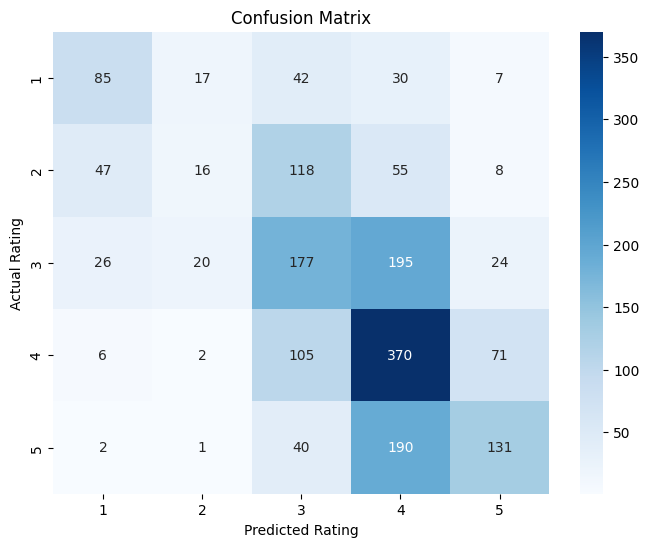

In [33]:
# 2. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for visualization
conf_df = pd.DataFrame(conf_matrix, index=[1,2,3,4,5], columns=[1,2,3,4,5])

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Confusion Matrix")
plt.show()

Hyperparameter tuning

In [34]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [None, 20, 40, 60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=30, scoring='accuracy', cv=3, verbose=2, n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
best_rf = random_search.best_estimator_
y_pred = rf_model.predict(X_test)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}


In [35]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Accuracy: 0.43641456582633054
              precision    recall  f1-score   support

         1.0      0.512     0.470     0.490       181
         2.0      0.286     0.066     0.107       244
         3.0      0.367     0.400     0.383       442
         4.0      0.440     0.668     0.531       554
         5.0      0.544     0.360     0.433       364

    accuracy                          0.436      1785
   macro avg      0.430     0.393     0.389      1785
weighted avg      0.429     0.436     0.412      1785



compare using different ML Algorithms

In [39]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Define models and hyperparameters
models = {
    "Logistic Regression": {
        "model": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000),
        "params": {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20],
            'class_weight': [None, 'balanced']
        }
    },
    "Linear SVC": {
        "model": LinearSVC(max_iter=2000),
        "params": {
            'C': [0.01, 0.1, 1, 10]
        }
    },
    "Multinomial NB": {
        "model": MultinomialNB(),
        "params": {
            'alpha': [0.5, 1.0, 2.0]
        }
    }
}

# Store results
results = []

# Loop through models
for name, mp in models.items():
    print(f"\n--- Training {name} ---")
    grid = GridSearchCV(mp["model"], mp["params"], cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    # Predictions
    y_pred = grid.best_estimator_.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Append results
    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# Display results in a DataFrame
results_df = pd.DataFrame(results)
print("\nFinal Model Comparison:")
print(results_df)


--- Training Logistic Regression ---


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Training Random Forest ---

--- Training Linear SVC ---

--- Training Multinomial NB ---

Final Model Comparison:
                 Model                                        Best Params  \
0  Logistic Regression                          {'C': 1, 'penalty': 'l2'}   
1        Random Forest  {'class_weight': 'balanced', 'max_depth': 20, ...   
2           Linear SVC                                         {'C': 0.1}   
3       Multinomial NB                                     {'alpha': 0.5}   

   Accuracy  Precision  Recall  F1-Score  
0    0.4527     0.4572  0.4527    0.4438  
1    0.4275     0.4259  0.4275    0.4175  
2    0.4555     0.4593  0.4555    0.4426  
3    0.4375     0.4582  0.4375    0.4080  


Trained it again in SVM-SVC

Fitting 3 folds for each of 90 candidates, totalling 270 fits

Best Parameters: {'C': 0.1, 'loss': 'squared_hinge', 'max_iter': 3000, 'tol': 0.01}

Accuracy: 0.45546218487394957

Classification Report:
               precision    recall  f1-score   support

         1.0      0.582     0.508     0.543       181
         2.0      0.420     0.152     0.223       244
         3.0      0.391     0.391     0.391       442
         4.0      0.437     0.625     0.514       554
         5.0      0.541     0.453     0.493       364

    accuracy                          0.455      1785
   macro avg      0.474     0.426     0.433      1785
weighted avg      0.459     0.455     0.443      1785



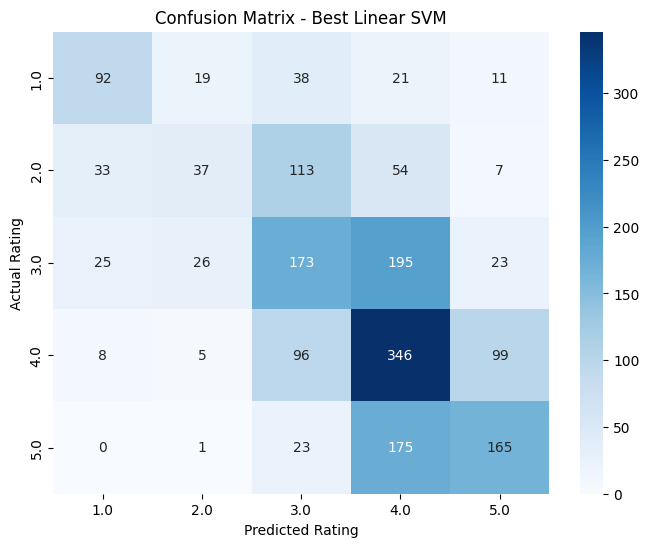

In [40]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Define Linear SVM model
svm_model = LinearSVC()

# Define parameter grid for tuning
param_grid = {
    'C': [0.01, 0.1, 1, 5, 10],
    'loss': ['hinge', 'squared_hinge'],
    'tol': [1e-4, 1e-3, 1e-2],
    'max_iter': [2000, 3000, 5000]
}

# Perform GridSearchCV
grid_search = GridSearchCV(
    svm_model,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("\nBest Parameters:", grid_search.best_params_)

# Best model after tuning
best_svm_model = grid_search.best_estimator_

# Predict on test set
y_pred_best_svm = best_svm_model.predict(X_test)

# Evaluation metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred_best_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_svm, digits=3))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_best_svm)
conf_df = pd.DataFrame(conf_matrix, index=sorted(y_test.unique()), columns=sorted(y_test.unique()))

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Confusion Matrix - Best Linear SVM")
plt.show()


saved trained model

In [42]:
import pickle

# Save the trained model to ModelB.pkl
with open('ModelB2.pkl', 'wb') as file:
    pickle.dump(best_svm_model, file)

print("ModelB1.pkl saved successfully.")

ModelB1.pkl saved successfully.


Cross test the models

Model_A (Balanced-trained) on Imbalanced Test Set:
Accuracy: 0.2006
Precision: 0.2484
Recall: 0.2006
F1-Score: 0.1993

Classification Report:
              precision    recall  f1-score   support

         1.0      0.137     0.337     0.195       181
         2.0      0.131     0.279     0.178       244
         3.0      0.266     0.253     0.260       442
         4.0      0.287     0.141     0.189       554
         5.0      0.302     0.107     0.158       364

    accuracy                          0.201      1785
   macro avg      0.225     0.223     0.196      1785
weighted avg      0.248     0.201     0.199      1785



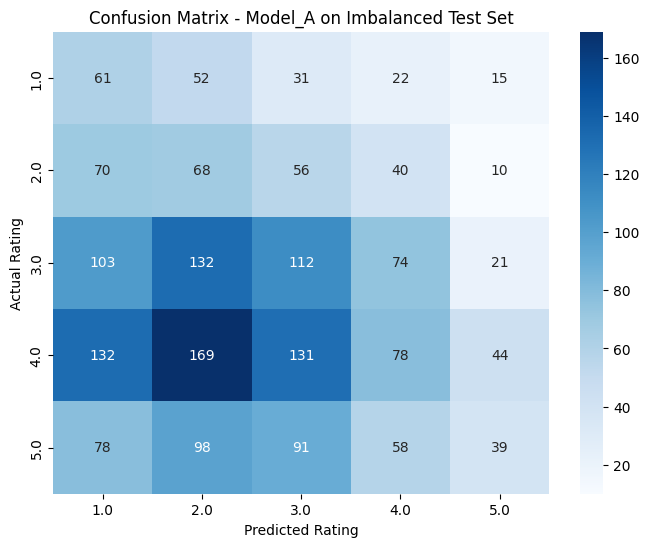

In [43]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Load the saved Model_A
model_a = joblib.load("Model_A.pkl")

# 2. Predict on imbalanced test set
y_pred_a = model_a.predict(X_test)  # X_test_imbalanced = TF-IDF features of your imbalanced test set

# 3. Evaluation Metrics
accuracy_a = accuracy_score(y_test, y_pred_a)
precision_a = precision_score(y_test, y_pred_a, average='weighted', zero_division=0)
recall_a = recall_score(y_test, y_pred_a, average='weighted', zero_division=0)
f1_a = f1_score(y_test, y_pred_a, average='weighted', zero_division=0)

print("Model_A (Balanced-trained) on Imbalanced Test Set:")
print(f"Accuracy: {accuracy_a:.4f}")
print(f"Precision: {precision_a:.4f}")
print(f"Recall: {recall_a:.4f}")
print(f"F1-Score: {f1_a:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_a, digits=3))

# 4. Confusion Matrix
conf_matrix_a = confusion_matrix(y_test, y_pred_a)
conf_df_a = pd.DataFrame(conf_matrix_a, index=sorted(y_test.unique()), columns=sorted(y_test.unique()))

plt.figure(figsize=(8,6))
sns.heatmap(conf_df_a, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Confusion Matrix - Model_A on Imbalanced Test Set")
plt.show()